In [1]:
import torch

tensor = torch.tensor([1.0, 2.0, 3.0])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# We move our tensor to the GPU if available
if torch.cuda.is_available():
  tensor = tensor.to('cuda')
  print(f"Device tensor is stored on: {tensor.device}")

Device tensor is stored on: cuda:0


In [2]:
import torch
import torchvision
import torchvision.transforms as transforms

print("modules loaded")

modules loaded


In [3]:

# clean data for validating and testing
test_transform = transforms.Compose([
    transforms.Resize(280),
    transforms.CenterCrop((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# augmented data for training
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(256),
    transforms.TrivialAugmentWide(),
    transforms.RandomHorizontalFlip(),
    # transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
weather_images = torchvision.datasets.ImageFolder(root='dataset')

# 3. Split the raw data
train_raw, test_raw, val_raw = torch.utils.data.random_split(weather_images, [0.6, 0.2, 0.2])

# 4. WRAP them in a class or apply transform manually
# In PyTorch, random_split returns a Subset. To give them different transforms:
class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)

# Dotychczasowy błąd polegał na tym, że trainset i valset używały tych samych transformacji.
# Nie powinny, ponieważ augmentacje powinny być stosowane tylko do zbioru treningowego.
# dlaczego? Bo augmentacje mają na celu zwiększenie różnorodności danych treningowych, co pomaga modelowi
# uczyć się bardziej ogólnych cech i unikać przeuczenia. Zbiór walidacyjny i testowy powinny odzwierciedlać rzeczywiste dane,
# na których model będzie działał, więc nie powinny zawierać sztucznych zmian.
trainset = ApplyTransform(train_raw, transform=train_transform)
testset = ApplyTransform(test_raw, transform=test_transform)
valset = ApplyTransform(val_raw, transform=test_transform)

batch_size = 64

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)


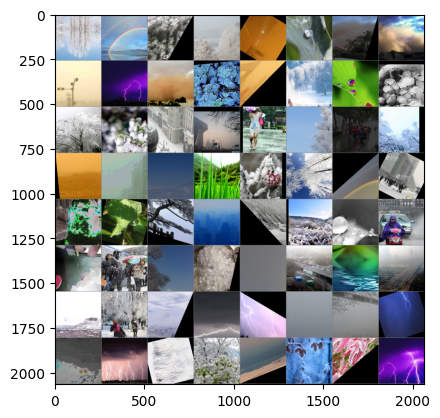

rime  rainbow glaze rime  sandstorm dew   sandstorm sandstorm sandstorm lightning sandstorm frost sandstorm rime  dew   hail  rime  glaze snow  fogsmog rain  rime  rain  rime  sandstorm fogsmog rainbow dew   rime  rime  rainbow snow  snow  dew   rime  fogsmog snow  snow  dew   rain  hail  snow  rime  hail  fogsmog sandstorm dew   fogsmog snow  rime  snow  lightning lightning fogsmog fogsmog lightning fogsmog lightning rime  rime  snow  frost frost lightning


torch.Size([3, 256, 256])

In [4]:
# sposób wyświetlenia obrazków i labelek

import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{trainloader.dataset.subset.dataset.classes[labels[j]]:5s}' for j in range(batch_size)))

images[0].shape

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch

import torch
import torch.nn as nn
import torch.nn.functional as F


# AI Pomogło
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        
        # First Convolution
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, 
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        # Second Convolution
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, 
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Shortcut connection (Identity mapping)
        self.shortcut = nn.Sequential()
        
        # If input/output dimensions don't match, we must transform the identity
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x
        
        # First convolution
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        # Second convolution
        out = self.conv2(out)
        out = self.bn2(out)
        
        # The core Residual logic: Element-wise addition
        out += self.shortcut(identity)
        out = F.relu(out)
        
        return out


class ResNet(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(ResNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 128, kernel_size=3, stride=1, padding=1, bias=False)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

        self.bn1 = nn.BatchNorm2d(128)
        self.res_layer_1 = self._make_layer(128, 256, stride=2)
        self.res_layer_2 = self._make_layer(256, 512, stride=1)
        self.res_layer_3 = self._make_layer(512, 1024, stride=1)


        # To sprawia, że niezależnie od rozmiaru wejściowego obrazu, wyjście z warstw konwolucyjnych będzie miało rozmiar 1x1 przed wejściem do warstwy w pełni połączonej - pytorch sam dobierze parametry poolowania by to zapewnić
        # Utracone informacje dotyczą umieszczenia features w obrazie, ale dla klasyfikacji całych obrazów nie ma to większego znaczenia
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        # mapowanie rezultatów na klasy
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_channels, out_channels, stride):
        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride))
        layers.append(ResidualBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        # First convolution - prepare for residual layers
        out = self.conv1(x)
        out = self.pool(out)
        out = self.bn1(out)
        out = F.relu(out)
        # print(out.size())

        # # Residual layers
        out = self.res_layer_1(out)
        out = self.res_layer_2(out)
        # out = self.res_layer_3(out)
        # print(out.size())
        # # Output from residual layers to fully connected layer
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

net = ResNet(3, trainloader.dataset.subset.dataset.classes.__len__())
net.to(device)
net = torch.compile(net)
print(net)

OptimizedModule(
  (_orig_mod): ResNet(
    (conv1): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (res_layer_1): Sequential(
      (0): ResidualBlock(
        (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (shortcut): Sequential(
          (0): Conv2d(128, 256, kernel_size=(1, 1), stride=(2, 2), bias=False)
          (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (1): ResidualBlo

In [6]:
torch.cuda.empty_cache()

In [7]:
from tqdm import trange
# Updated tracking structures

# - Zero (the gradients)

# - Forward (get predictions)

# - Loss (calculate error)

# - Backward (calculate gradients)

# - Step (update weights)

torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')

print("START TRAINING")
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
EPOCHS = 50
import torch.optim as optim

lr = 1e-2
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(net.parameters(), lr=lr, betas=(0.9, 0.999), weight_decay=1e-4)

for epoch in (pbar := trange(1, EPOCHS+1)):
    net.train()
    running_train_loss = 0.0
    
    for i, (inputs, labels) in enumerate(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad(set_to_none=True)
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        pbar.set_description(f"epoch: {epoch}, iter: {i}/{len(trainloader)}, train_loss: {loss.item()}")

    # Calculate average epoch loss
    epoch_train_loss = running_train_loss / len(trainloader)
    
    # Validation Phase
    net.eval()
    running_val_loss = 0.0
    correct = 0
    
    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            running_val_loss += criterion(outputs, labels).item()
            
            pred = outputs.argmax(dim=1)
            correct += (pred == labels).sum().item()

    epoch_val_loss = running_val_loss / len(valloader)
    epoch_val_acc = correct / len(valloader.dataset)

    # Store metrics once per epoch for clean plotting
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    torch.save(net.state_dict(), 'checkpoints/resnet_epoch_{}.pth'.format(epoch+1))

    # early stopping if Val Loss does not improve for 5 consecutive epochs
    # if epoch > 5:
    #     if all(history['val_loss'][-1] >= history['val_loss'][-i] for i in range(2, 2 + 5)):
    #         print("Early stopping triggered")
    #         break

    print(f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

torch.save(net.state_dict(), 'weather_resnet.pth')

START TRAINING


epoch: 1, iter: 64/65, train_loss: 1.4502135515213013:   2%|▏         | 1/50 [00:51<42:05, 51.54s/it]

Epoch 2 | Train Loss: 2.1943 | Val Loss: 1.6541


epoch: 2, iter: 64/65, train_loss: 1.8072079420089722:   4%|▍         | 2/50 [01:16<28:43, 35.91s/it]

Epoch 3 | Train Loss: 1.6537 | Val Loss: 1.4863


...

Epoch 49 | Train Loss: 0.9105 | Val Loss: 0.7498


epoch: 49, iter: 64/65, train_loss: 0.9866489768028259:  98%|█████████▊| 49/50 [19:06<00:22, 22.74s/it]

Epoch 50 | Train Loss: 0.9409 | Val Loss: 0.7366


epoch: 50, iter: 64/65, train_loss: 1.2077054977416992: 100%|██████████| 50/50 [19:29<00:00, 23.38s/it]

Epoch 51 | Train Loss: 0.9265 | Val Loss: 0.7088


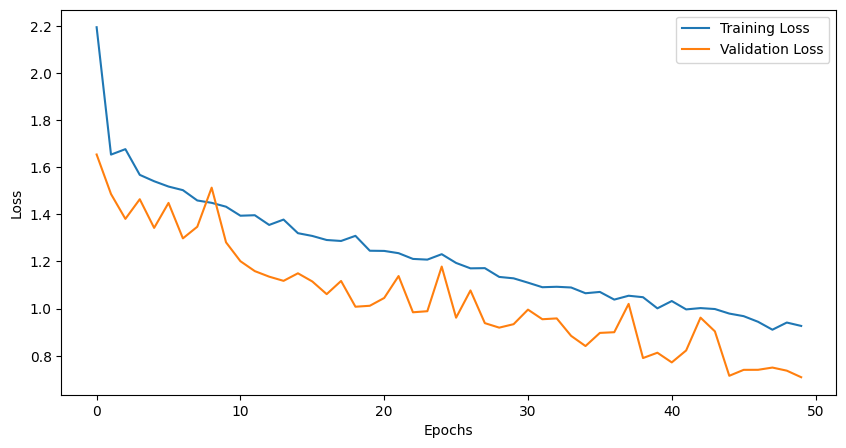

In [8]:
plt.figure(figsize=(10,5))
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [9]:
params = list(net.parameters())
print(len(params))
print(params[0].size())  # conv1's .weight

50
torch.Size([128, 3, 3, 3])


In [13]:
# Wyznaczanie całkowitej jakości klasyfikacji sieci na zbiorze testowym
classes = trainloader.dataset.subset.dataset.classes
net = ResNet(3, len(classes))
net.to(device)
net = torch.compile(net)
net.load_state_dict(torch.load('checkpoints/resnet_epoch_50.pth'))
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images.to(device))
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels.to(device)).sum().item()
print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 78 %


In [14]:
# Wyznaczanie jakości klasyfikacji dla poszczególnych klas

# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images.to('cuda'))
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels.to('cuda'), predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: dew   is 84.4 %
Accuracy for class: fogsmog is 94.4 %
Accuracy for class: frost is 66.0 %
Accuracy for class: glaze is 50.0 %
Accuracy for class: hail  is 87.9 %
Accuracy for class: lightning is 100.0 %
Accuracy for class: rain  is 80.4 %
Accuracy for class: rainbow is 69.2 %
Accuracy for class: rime  is 80.8 %
Accuracy for class: sandstorm is 83.1 %
Accuracy for class: snow  is 62.6 %


fogsmog frost rain  rime  rain  snow  rain  sandstorm glaze fogsmog rain  fogsmog hail  rime  hail  dew   rain  rime  glaze dew   rime  lightning fogsmog rain  sandstorm fogsmog glaze lightning dew   glaze rain  fogsmog fogsmog rime  rime  dew   hail  rain  rainbow rain  rainbow hail  rime  rime  snow  rain  lightning lightning fogsmog sandstorm rime  rime  hail  frost frost sandstorm snow  lightning hail  sandstorm rime  frost sandstorm dew  


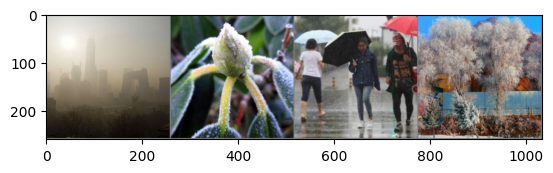

Predicted: fogsmog, Actual: fogsmog
Predicted: frost, Actual: frost
Predicted: rain, Actual: rain
Predicted: rime, Actual: rime


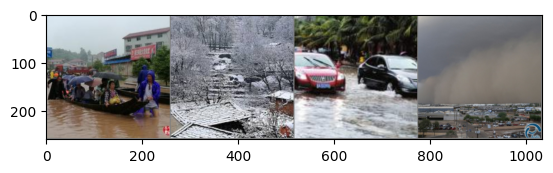

Predicted: rain, Actual: rain
Predicted: rime, Actual: snow
Predicted: rain, Actual: rain
Predicted: sandstorm, Actual: sandstorm


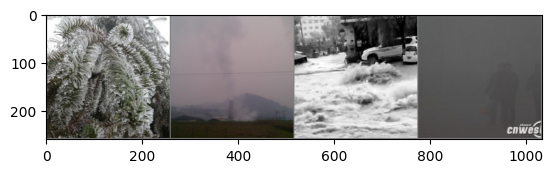

Predicted: glaze, Actual: glaze
Predicted: sandstorm, Actual: fogsmog
Predicted: snow, Actual: rain
Predicted: fogsmog, Actual: fogsmog


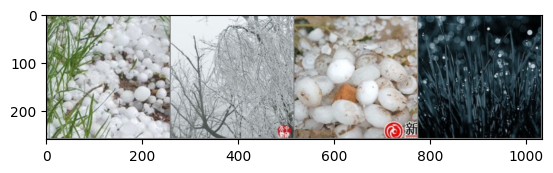

Predicted: hail, Actual: hail
Predicted: rime, Actual: rime
Predicted: hail, Actual: hail
Predicted: rain, Actual: dew


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()
# get some random training images
dataiter = iter(testloader)
images, labels = next(dataiter)

outputs = net(images.to('cuda'))
_, predicted = torch.max(outputs, 1)

# show images
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

images[0].shape

# display 4 at time
for i in range(4):
    imshow(torchvision.utils.make_grid(images[i*4:4+i*4].cpu()))
    for j in range(4):
        print(f'Predicted: {classes[predicted[i*4+j]]}, Actual: {classes[labels[i*4+j]]}')